In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [15]:
X , y = make_blobs(

      n_samples = 1000,
      n_features = 2,
      centers = 4,
      random_state =42
      
    
)# taken smaple values for unsupervised ML algo

In [16]:
X

array([[-8.55503989,  7.06461794],
       [-6.13753182, -6.58081701],
       [-6.32130028, -6.8041042 ],
       ...,
       [ 3.69047995,  4.60555175],
       [-7.48913939, -7.0670809 ],
       [-9.40049578,  7.11430104]], shape=(1000, 2))

<Axes: >

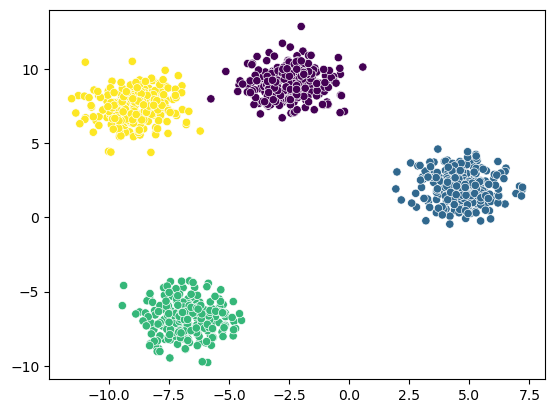

In [20]:
# Visualize 

sns.scatterplot(x = X[:, 0] , y = X[: , 1] , c =y)

In [22]:
from sklearn.cluster import KMeans

In [38]:
K = 4
kmeans = KMeans(

   n_clusters = K,
   random_state = 42,
    init = "k-means++"
    
) 
# Step1) Intaize K value 
# Step2) Intaize centroid vlaue by kmeans++(By default)

In [39]:
kmeans


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [40]:
labels = kmeans.fit_predict(X)
#labels = cluster number
# step3) Each data pt cal distance from all centroid , min value data pt particluar centroid assign
# step4) cal mean value for particular cluster , centroid mean value shift
# step5) Again step 3 & 4 repeat untill we get conergance , best value
# Output - Where our each data pt perfectly assign to a particular cluster(label = clutser number)

In [41]:
labels.shape

(1000,)

<Axes: >

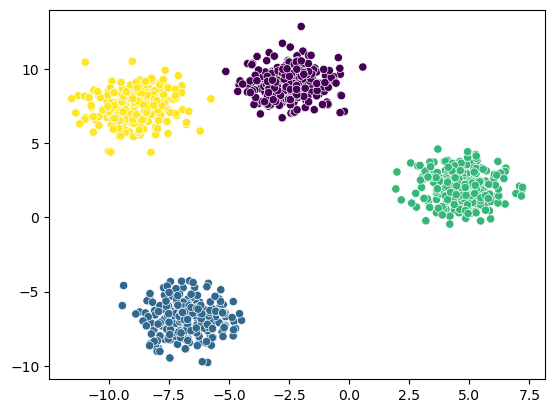

In [42]:
sns.scatterplot(x = X[: ,0] , y= X[: , 1] , c=labels)

## Choose K value using elbow method

In [52]:
wcss = []
var = []

for k in range(1, 21):
    kmeans = KMeans(n_clusters = k)
    var = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

In [56]:
var.shape

(1000,)

In [53]:
wcss

[66908.2849051687,
 33347.48204835135,
 7324.560564741558,
 1948.732919385683,
 1776.4093495448515,
 1634.9456889076268,
 1471.5820909949716,
 1360.2502440733294,
 1151.8619605485155,
 1110.4428347836633,
 964.9133746281718,
 987.6018331878715,
 885.8068336964178,
 772.684973433509,
 748.7468176649475,
 732.6543549193538,
 687.9780176754409,
 630.8656321229505,
 626.5813555871844,
 563.9873100426391]

<Axes: >

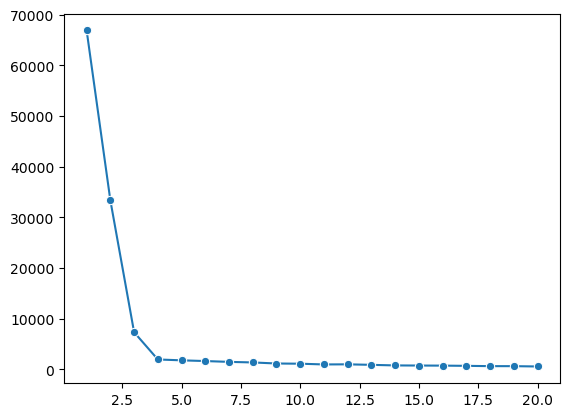

In [54]:
sns.lineplot(x = range(1,21)  , y = wcss , marker = 'o')

In [57]:
# Kneed package to find out the value of elbow pt (Automatically)

!pip install kneed

In [60]:
from kneed import KneeLocator  # here Kneed - package and Kneelocator = class
knee = KneeLocator(range(1,21) , wcss , curve = "convex" , direction = "decreasing")
#knee = KneeLocator(x , y , curve = "convex" , direction = "decreasing")
#knee - object or instance of class KneeLocator

In [62]:
print("optimal k", knee.elbow)

optimal k 4


### choose K value using silhouette score

In [63]:
from sklearn.metrics import silhouette_score

In [66]:
ss = []  # empty list

for k in range(2,21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X , labels)
    ss.append(score)

In [67]:
ss

[0.5895787972208197,
 0.7521964163365819,
 0.7915983870089952,
 0.6805323281756999,
 0.6779496114112614,
 0.46184540482845815,
 0.421550116417234,
 0.43044079037325067,
 0.3367581957096638,
 0.31483930436216134,
 0.33320324172395294,
 0.3320728420226909,
 0.33274429685541956,
 0.3309027958690964,
 0.31058045385027194,
 0.31197976697398255,
 0.31631437110688376,
 0.31976313074129514,
 0.33094431246682426]

<Axes: >

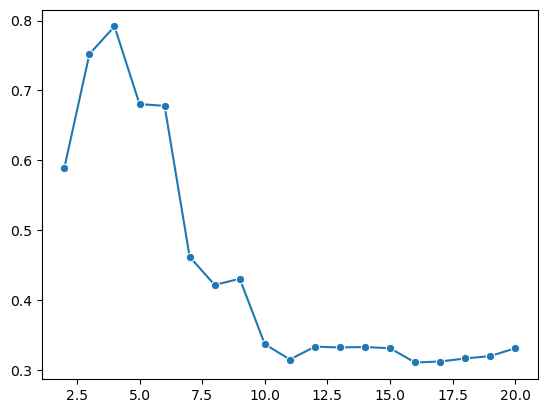

In [69]:
sns.lineplot(x = range(2,21) ,y=  ss , marker = 'o' )

In [72]:
ss[5:10]

[0.46184540482845815,
 0.421550116417234,
 0.43044079037325067,
 0.3367581957096638,
 0.31483930436216134]